TEST

Task 1: Initial Exploration 

In [1]:
# Import          
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore   
import seaborn as sns



In [2]:
# load dataset 
df=pd.read_csv('synthetic_dataset.csv')


In [3]:
df

,Category,Price,Rating,Stock,Discount
0,NaN,5548.0,1.870322,NaN,0.0
1,NaN,3045.0,4.757798,NaN,38.0
2,NaN,4004.0,NaN,In Stock,0.0
3,NaN,4808.0,1.492085,NaN,33.0
4,NaN,1817.0,NaN,Out of Stock,23.0
...,...,...,...,...,...
4357,NaN,4436.0,4.728335,NaN,49.0
4358,B,6236.0,NaN,Out of Stock,4.0
4359,NaN,3283.0,NaN,Out of Stock,9.0
4360,D,2999.0,4.425995,NaN,40.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4362 entries, 0 to 4361
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  1614 non-null   str    
 1   Price     4188 non-null   float64
 2   Rating    2312 non-null   float64
 3   Stock     3010 non-null   str    
 4   Discount  3970 non-null   float64
dtypes: float64(3), str(2)
memory usage: 170.5 KB


In [5]:
df.describe()

,Price,Rating,Discount
count,4188.000000,2312.000000,3970.000000
mean,5016.970630,3.038293,24.516625
std,2839.984813,1.143074,14.347164
min,102.000000,1.000366,0.000000
25%,2628.250000,2.069490,12.000000
50%,4996.500000,3.082060,25.000000
75%,7418.000000,4.008620,37.000000
max,9999.000000,4.997818,49.000000


In [6]:
df.head() 
# first 5 

,Category,Price,Rating,Stock,Discount
0,NaN,5548.0,1.870322,NaN,0.0
1,NaN,3045.0,4.757798,NaN,38.0
2,NaN,4004.0,NaN,In Stock,0.0
3,NaN,4808.0,1.492085,NaN,33.0
4,NaN,1817.0,NaN,Out of Stock,23.0


In [7]:
df.tail()
# last 5

,Category,Price,Rating,Stock,Discount
4357,NaN,4436.0,4.728335,NaN,49.0
4358,B,6236.0,NaN,Out of Stock,4.0
4359,NaN,3283.0,NaN,Out of Stock,9.0
4360,D,2999.0,4.425995,NaN,40.0
4361,NaN,NaN,2.184471,NaN,0.0


In [8]:
df.isnull().sum()  
# missing value 

Category    2748
Price        174
Rating      2050
Stock       1352
Discount     392
dtype: int64

In [9]:
df.shape

(4362, 5)

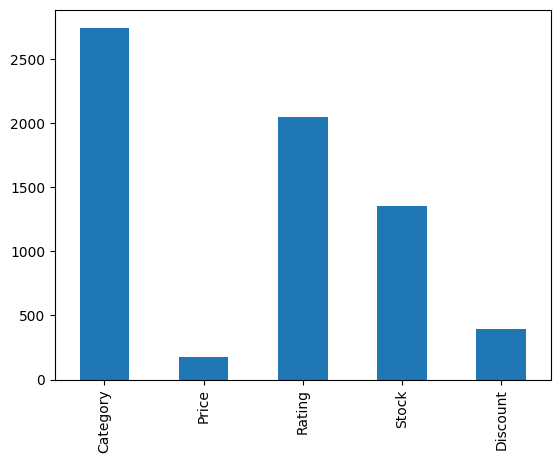

In [10]:
df.isnull().sum().plot(kind='bar')
plt.show()


Task 2: Understanding Data Characteristics 

In [22]:
# identify which attributes are numerical and which are categorical

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'string']).columns

# b. Print the numerical and categorical columns. 


# Print numerical columns
print("\nNumerical Columns:")
print(numerical_cols)

# Print categorical columns
print("\nCategorical Columns:")
print(categorical_cols)


df.describe()




Numerical Columns:
Index(['Price', 'Rating', 'Discount'], dtype='str')

Categorical Columns:
Index(['Category', 'Stock'], dtype='str')


,Price,Rating,Discount
count,2019.000000,2019.000000,2019.000000
mean,5070.635958,3.050905,24.360575
std,2853.328749,1.142364,14.569602
min,102.000000,1.000366,0.000000
25%,2699.000000,2.089793,12.000000
50%,5114.000000,3.082219,24.000000
75%,7492.000000,4.023063,37.000000
max,9999.000000,4.997818,49.000000


Task 3: Identifying Unusual Observations

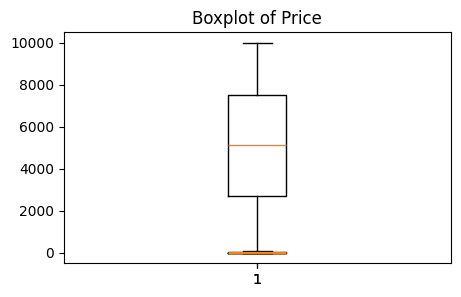

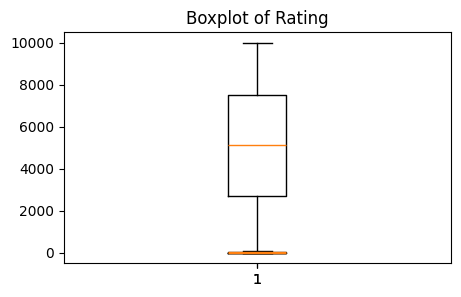

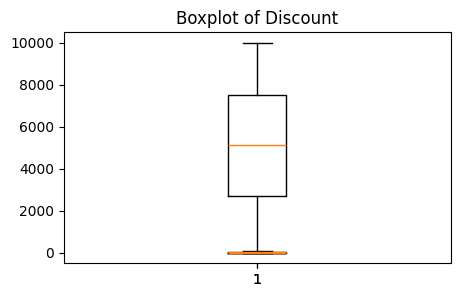

In [19]:
for col in numerical_cols:    
    plt.figure(figsize=(5,3))  
    plt.title("Boxplot of " + col)
    plt.boxplot(df['Price'])
    plt.boxplot(df['Discount'])
    plt.boxplot(df['Rating'])
    plt.show()


In [13]:
# Detecting outliers using IQR method
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
print(f"\nNumber of outliers in {col}: {len(outliers)}")


Number of outliers in Discount: 0


Task 4: Improving Data Quality 

In [14]:
df.isnull().sum()  #check for missing values

Category    2748
Price        174
Rating      2050
Stock       1352
Discount     392
dtype: int64

In [21]:

# Handling numerical missing values
for col in numerical_cols:
    df.fillna({col: df[col].median()}, inplace=True)

# Handling categorical missing values
for col in categorical_cols:
    df.fillna({col: df[col].mode()[0]}, inplace=True)

In [16]:
df

,Category,Price,Rating,Stock,Discount
0,NaN,5548.0,1.870322,NaN,0.0
1,NaN,3045.0,4.757798,NaN,38.0
2,NaN,4004.0,NaN,In Stock,0.0
3,NaN,4808.0,1.492085,NaN,33.0
4,NaN,1817.0,NaN,Out of Stock,23.0
...,...,...,...,...,...
4357,NaN,4436.0,4.728335,NaN,49.0
4358,B,6236.0,NaN,Out of Stock,4.0
4359,NaN,3283.0,NaN,Out of Stock,9.0
4360,D,2999.0,4.425995,NaN,40.0


In [17]:
# Removing outliers using IQR

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]


print("\nDataset shape after cleaning:", df.shape)



Dataset shape after cleaning: (2019, 5)


In [18]:
df.shape

(2019, 5)